## 02 - Sales Ranking and Customer Pain Analysis

### Objetivo
Responder a las siguientes preguntas:

1. ¿Cuáles son los 5 productos o categorías más vendidos en términos de volumen y cuáles en términos de ingresos totales?
2. ¿Cuál es el mayor dolor de nuestros clientes y qué productos o categorías están directamente relacionados con estas malas experiencias?

### Decisiones metodológicas
- **Volumen**: número de ítems vendidos (`quantity = 1` por fila de `order_items_dataset`).
- **Ingresos por producto/categoría**: suma de `order_items.price`.
- **Base principal**: órdenes con `order_status == "delivered"`.
- **Experiencia del cliente**:
  - señal cuantitativa principal: `review_score`
  - señal operativa: retraso de entrega (`delivery_delay_days > 0`)
  - señal cualitativa: `review_comment_message` cuando existe
- **Limitación importante**:
  la review está a nivel orden, no a nivel ítem. Sin embargo, como en el EDA se observó que la mayoría de órdenes tienen un solo ítem, esta aproximación es razonable para análisis de negocio.

In [1]:
from pathlib import Path
import sys
import re
from collections import Counter

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.data.loaders import load_all_datasets

print("PROJECT_ROOT:", PROJECT_ROOT)

PROJECT_ROOT: D:\Users\dhcertug\OneDrive - Crystal S.A.S\Escritorio\commercial-analytics-ai-challenge


In [3]:
bundle = load_all_datasets()

customers = bundle.customers.copy()
order_items = bundle.order_items.copy()
order_payments = bundle.order_payments.copy()
order_reviews = bundle.order_reviews.copy()
orders = bundle.orders.copy()
products = bundle.products.copy()
translation = bundle.product_category_translation.copy()
sellers = bundle.sellers.copy()

### Construcción de la base analítica 

Se construye una base a nivel ítem entregado, enriquecida con:
- pedido,
- producto,
- categoría,
- cliente,
- seller,
- review agregada,
- pagos agregados,
- señales de retraso.

In [4]:
reviews_agg = (
    order_reviews
    .sort_values(["order_id", "review_creation_date"], ascending=[True, False], na_position="last")
    .groupby("order_id", as_index=False)
    .agg(
        review_score=("review_score", "mean"),
        review_comment_title=("review_comment_title", "first"),
        review_comment_message=("review_comment_message", "first"),
    )
)

payments_agg = (
    order_payments.groupby("order_id", as_index=False)
    .agg(
        payment_value_total=("payment_value", "sum"),
        payment_installments_max=("payment_installments", "max"),
        payment_type_nunique=("payment_type", "nunique"),
    )
)

delivered_orders = orders.loc[orders["order_status"] == "delivered"].copy()

item_base = (
    order_items
    .merge(delivered_orders, on="order_id", how="inner", validate="many_to_one")
    .merge(products, on="product_id", how="left", validate="many_to_one")
    .merge(translation, on="product_category_name", how="left", validate="many_to_one")
    .merge(customers, on="customer_id", how="left", validate="many_to_one")
    .merge(sellers, on="seller_id", how="left", validate="many_to_one")
    .merge(reviews_agg, on="order_id", how="left", validate="many_to_one")
    .merge(payments_agg, on="order_id", how="left", validate="many_to_one")
)

item_base["product_category"] = (
    item_base["product_category_name_english"]
    .fillna(item_base["product_category_name"])
    .fillna("unknown")
)

item_base["quantity"] = 1
item_base["item_revenue"] = item_base["price"].fillna(0.0)
item_base["gross_revenue"] = item_base["price"].fillna(0.0) + item_base["freight_value"].fillna(0.0)

item_base["delivery_delay_days"] = (
    item_base["order_delivered_customer_date"] - item_base["order_estimated_delivery_date"]
).dt.days

item_base["is_late_delivery"] = item_base["delivery_delay_days"] > 0
item_base["is_bad_review"] = item_base["review_score"].fillna(5) <= 2
item_base["is_neutral_or_worse_review"] = item_base["review_score"].fillna(5) <= 3
item_base["has_comment"] = item_base["review_comment_message"].fillna("").str.strip().ne("")

item_base.shape

(110197, 45)

In [5]:
item_base[[
    "order_id",
    "order_item_id",
    "product_id",
    "product_category",
    "order_status",
    "price",
    "freight_value",
    "item_revenue",
    "gross_revenue",
    "review_score",
    "delivery_delay_days",
    "is_late_delivery",
    "is_bad_review",
]].head(10)

,order_id,order_item_id,product_id,product_category,order_status,price,freight_value,item_revenue,gross_revenue,review_score,delivery_delay_days,is_late_delivery,is_bad_review
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,cool_stuff,delivered,58.90,13.29,58.90,72.19,5.00,-9.00,False,False
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,pet_shop,delivered,239.90,19.93,239.90,259.83,4.00,-3.00,False,False
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,furniture_decor,delivered,199.00,17.87,199.00,216.87,5.00,-14.00,False,False
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,perfumery,delivered,12.99,12.79,12.99,25.78,4.00,-6.00,False,False
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,garden_tools,delivered,199.90,18.14,199.90,218.04,5.00,-16.00,False,False
5,00048cc3ae777c65dbb7d2a0634bc1ea,1,ef92defde845ab8450f9d70c526ef70f,housewares,delivered,21.90,12.69,21.90,34.59,4.00,-15.00,False,False
6,00054e8431b9d7675808bcb819fb4a32,1,8d4f2bb7e93e6710a28f34fa83ee7d28,telephony,delivered,19.90,11.85,19.90,31.75,4.00,-17.00,False,False
7,000576fe39319847cbb9d288c5617fa6,1,557d850972a7d6f792fd18ae1400d9b6,garden_tools,delivered,810.00,70.75,810.00,880.75,5.00,-16.00,False,False
8,0005a1a1728c9d785b8e2b08b904576c,1,310ae3c140ff94b03219ad0adc3c778f,health_beauty,delivered,145.95,11.65,145.95,157.60,1.00,0.00,False,True
9,0005f50442cb953dcd1d21e1fb923495,1,4535b0e1091c278dfd193e5a1d63b39f,books_technical,delivered,53.99,11.40,53.99,65.39,4.00,-19.00,False,False


In [6]:
## Sanity checks 
sanity = pd.DataFrame({
    "metric": [
        "delivered_orders",
        "delivered_item_rows",
        "distinct_products",
        "distinct_categories",
        "distinct_customers",
        "late_delivery_rate",
        "bad_review_rate",
        "neutral_or_worse_review_rate",
    ],
    "value": [
        delivered_orders["order_id"].nunique(),
        len(item_base),
        item_base["product_id"].nunique(),
        item_base["product_category"].nunique(),
        item_base["customer_unique_id"].nunique(),
        item_base["is_late_delivery"].mean(),
        item_base["is_bad_review"].mean(),
        item_base["is_neutral_or_worse_review"].mean(),
    ]
})

sanity

,metric,value
0,delivered_orders,"96,478.00"
1,delivered_item_rows,"110,197.00"
2,distinct_products,"32,216.00"
3,distinct_categories,74.00
4,distinct_customers,"93,358.00"
5,late_delivery_rate,0.07
6,bad_review_rate,0.15
7,neutral_or_worse_review_rate,0.23


### 1. Top 5 productos y categorías por volumen e ingresos

Se construirán dos niveles de ranking:
- **producto**
- **categoría**

Y dos métricas:
- **volumen**
- **ingresos**

In [7]:
product_sales = (
    item_base.groupby("product_id", as_index=False)
    .agg(
        product_category=("product_category", lambda s: s.mode().iloc[0] if not s.mode().empty else "unknown"),
        total_volume=("quantity", "sum"),
        total_revenue=("item_revenue", "sum"),
        total_gross_revenue=("gross_revenue", "sum"),
        n_orders=("order_id", "nunique"),
        avg_price=("price", "mean"),
        avg_review_score=("review_score", "mean"),
    )
)

category_sales = (
    item_base.groupby("product_category", as_index=False)
    .agg(
        total_volume=("quantity", "sum"),
        total_revenue=("item_revenue", "sum"),
        total_gross_revenue=("gross_revenue", "sum"),
        n_orders=("order_id", "nunique"),
        n_products=("product_id", "nunique"),
        avg_price=("price", "mean"),
        avg_review_score=("review_score", "mean"),
    )
)

In [8]:
top_products_volume = (
    product_sales
    .sort_values(["total_volume", "total_revenue"], ascending=[False, False])
    .head(5)
    .reset_index(drop=True)
)

top_products_revenue = (
    product_sales
    .sort_values(["total_revenue", "total_volume"], ascending=[False, False])
    .head(5)
    .reset_index(drop=True)
)

top_categories_volume = (
    category_sales
    .sort_values(["total_volume", "total_revenue"], ascending=[False, False])
    .head(5)
    .reset_index(drop=True)
)

top_categories_revenue = (
    category_sales
    .sort_values(["total_revenue", "total_volume"], ascending=[False, False])
    .head(5)
    .reset_index(drop=True)
)

#### Top 5 productos por volumen

In [9]:
top_products_volume

,product_id,product_category,total_volume,total_revenue,total_gross_revenue,n_orders,avg_price,avg_review_score
0,aca2eb7d00ea1a7b8ebd4e68314663af,furniture_decor,520,"37,104.30","44,197.75",425,71.35,4.05
1,422879e10f46682990de24d770e7f83d,garden_tools,484,"26,577.22","34,201.26",352,54.91,3.96
2,99a4788cb24856965c36a24e339b6058,bed_bath_table,477,"42,049.66","49,907.50",456,88.15,3.93
3,389d119b48cf3043d311335e499d9c6b,garden_tools,390,"21,336.79","28,543.65",309,54.71,4.13
4,368c6c730842d78016ad823897a372db,garden_tools,388,"21,056.80","27,984.40",291,54.27,3.92


#### Top 5 productos por ingresos

In [10]:
top_products_revenue

,product_id,product_category,total_volume,total_revenue,total_gross_revenue,n_orders,avg_price,avg_review_score
0,bb50f2e236e5eea0100680137654686c,health_beauty,194,"63,560.00","67,258.03",186,327.63,4.24
1,6cdd53843498f92890544667809f1595,health_beauty,153,"53,652.30","57,933.73",148,350.67,4.36
2,d6160fb7873f184099d9bc95e30376af,computers,33,"45,949.35","47,314.18",33,"1,392.40",4.67
3,d1c427060a0f73f6b889a5c7c61f2ac4,computers_accessories,332,"45,620.56","58,957.31",313,137.41,4.28
4,99a4788cb24856965c36a24e339b6058,bed_bath_table,477,"42,049.66","49,907.50",456,88.15,3.93


#### Top 5 categorías por volumen

In [11]:
top_categories_volume

,product_category,total_volume,total_revenue,total_gross_revenue,n_orders,n_products,avg_price,avg_review_score
0,bed_bath_table,10953,"1,023,434.76","1,225,209.26",9272,2991,93.44,3.92
1,health_beauty,9465,"1,233,131.72","1,412,089.53",8647,2397,130.28,4.19
2,sports_leisure,8431,"954,852.55","1,118,256.91",7530,2822,113.25,4.17
3,furniture_decor,8160,"711,927.69","880,329.92",6307,2593,87.25,3.95
4,computers_accessories,7644,"888,724.61","1,032,723.77",6530,1600,116.26,3.99


#### Top 5 categorías por ingresos

In [12]:
top_categories_revenue

,product_category,total_volume,total_revenue,total_gross_revenue,n_orders,n_products,avg_price,avg_review_score
0,health_beauty,9465,"1,233,131.72","1,412,089.53",8647,2397,130.28,4.19
1,watches_gifts,5859,"1,166,176.98","1,264,333.12",5495,1300,199.04,4.07
2,bed_bath_table,10953,"1,023,434.76","1,225,209.26",9272,2991,93.44,3.92
3,sports_leisure,8431,"954,852.55","1,118,256.91",7530,2822,113.25,4.17
4,computers_accessories,7644,"888,724.61","1,032,723.77",6530,1600,116.26,3.99


### 1.2. Visualización de Q1

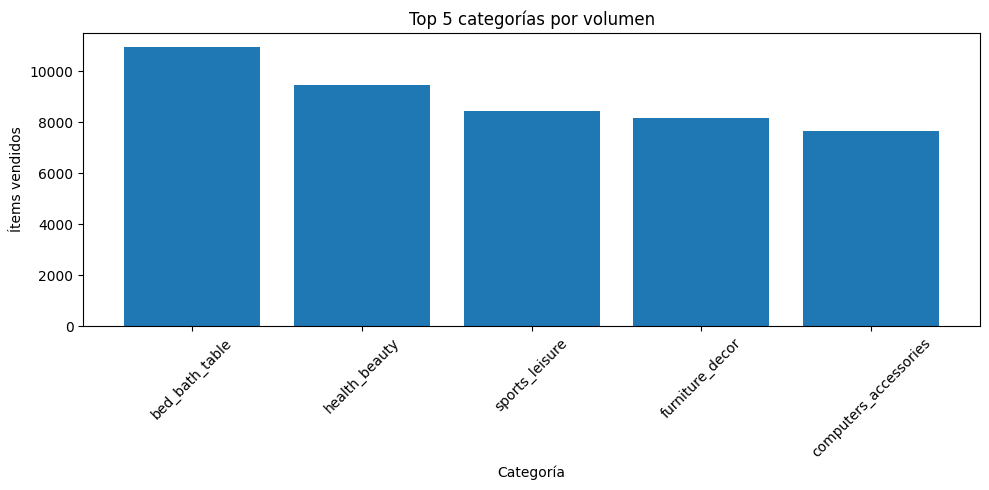

In [13]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(top_categories_volume["product_category"], top_categories_volume["total_volume"])
ax.set_title("Top 5 categorías por volumen")
ax.set_xlabel("Categoría")
ax.set_ylabel("Ítems vendidos")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

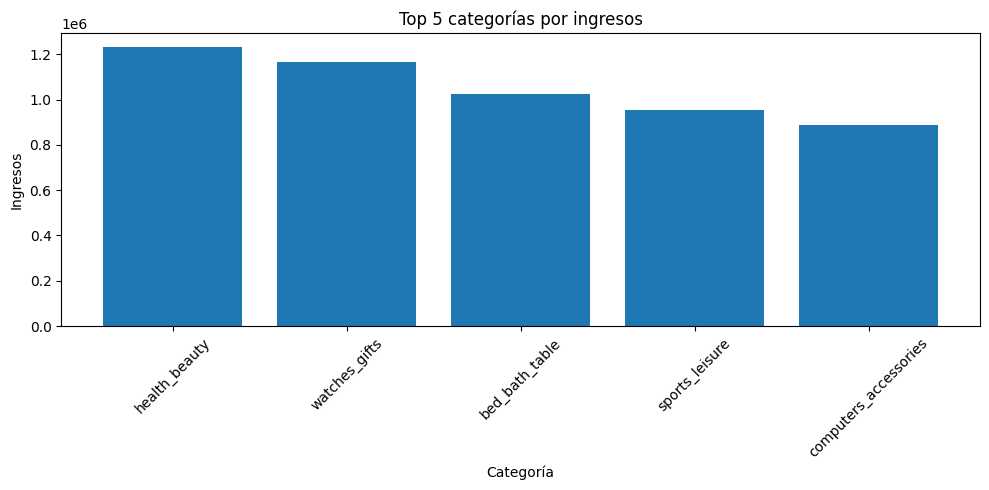

In [14]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(top_categories_revenue["product_category"], top_categories_revenue["total_revenue"])
ax.set_title("Top 5 categorías por ingresos")
ax.set_xlabel("Categoría")
ax.set_ylabel("Ingresos")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

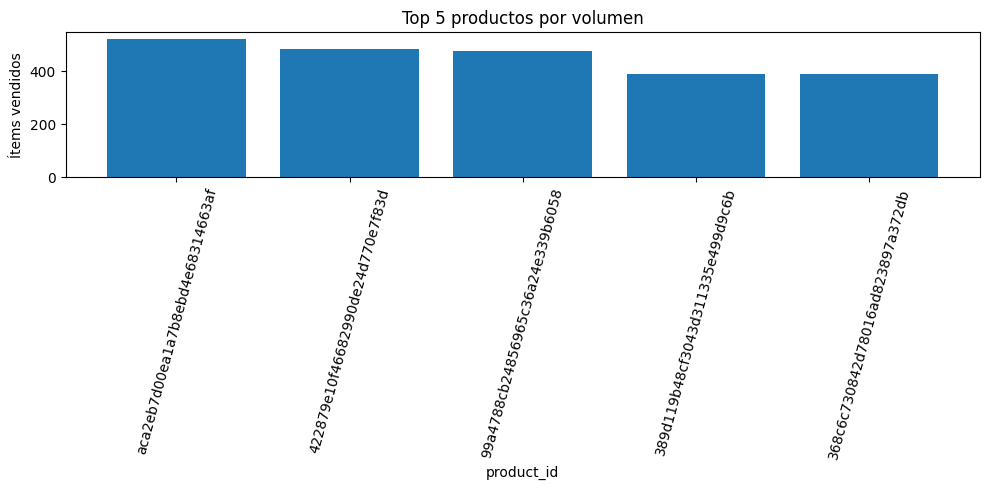

In [15]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(top_products_volume["product_id"], top_products_volume["total_volume"])
ax.set_title("Top 5 productos por volumen")
ax.set_xlabel("product_id")
ax.set_ylabel("Ítems vendidos")
ax.tick_params(axis="x", rotation=75)
plt.tight_layout()
plt.show()

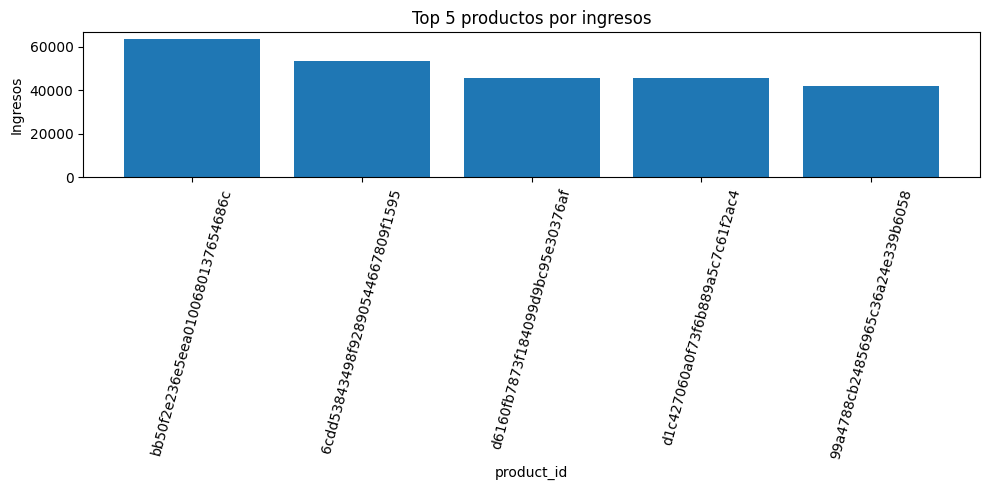

In [16]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(top_products_revenue["product_id"], top_products_revenue["total_revenue"])
ax.set_title("Top 5 productos por ingresos")
ax.set_xlabel("product_id")
ax.set_ylabel("Ingresos")
ax.tick_params(axis="x", rotation=75)
plt.tight_layout()
plt.show()

### 1.3. Lectura ejecutiva preliminar de Q1

In [17]:
q1_exec = pd.DataFrame({
    "view": [
        "Top categories by volume",
        "Top categories by revenue",
        "Top products by volume",
        "Top products by revenue",
    ],
    "top_1": [
        top_categories_volume.loc[0, "product_category"],
        top_categories_revenue.loc[0, "product_category"],
        top_products_volume.loc[0, "product_id"],
        top_products_revenue.loc[0, "product_id"],
    ],
    "top_1_metric": [
        top_categories_volume.loc[0, "total_volume"],
        top_categories_revenue.loc[0, "total_revenue"],
        top_products_volume.loc[0, "total_volume"],
        top_products_revenue.loc[0, "total_revenue"],
    ]
})

q1_exec

,view,top_1,top_1_metric
0,Top categories by volume,bed_bath_table,"10,953.00"
1,Top categories by revenue,health_beauty,"1,233,131.72"
2,Top products by volume,aca2eb7d00ea1a7b8ebd4e68314663af,520.00
3,Top products by revenue,bb50f2e236e5eea0100680137654686c,"63,560.00"


### 2. ¿Cuál es el mayor dolor del cliente?

Se evaluarán dos hipótesis:

### Hipótesis A — dolor logístico
Las malas experiencias están fuertemente asociadas a retrasos de entrega.

### Hipótesis B — dolor de producto/expectativa
Hay categorías o productos con malas experiencias inherentes a otros factores.

In [18]:
overall_pain = pd.DataFrame({
    "metric": [
        "avg_review_score",
        "bad_review_rate",
        "neutral_or_worse_review_rate",
        "late_delivery_rate",
        "avg_delivery_delay_days",
        "median_delivery_delay_days",
    ],
    "value": [
        item_base["review_score"].mean(),
        item_base["is_bad_review"].mean(),
        item_base["is_neutral_or_worse_review"].mean(),
        item_base["is_late_delivery"].mean(),
        item_base["delivery_delay_days"].mean(),
        item_base["delivery_delay_days"].median(),
    ]
})

overall_pain

,metric,value
0,avg_review_score,4.08
1,bad_review_rate,0.15
2,neutral_or_worse_review_rate,0.23
3,late_delivery_rate,0.07
4,avg_delivery_delay_days,-12.03
5,median_delivery_delay_days,-13.00


In [19]:
## Impacto del retraso sobre la experiencia

delay_crosstab = pd.crosstab(
    item_base["is_late_delivery"],
    item_base["is_bad_review"],
    normalize="index"
).rename(columns={False: "not_bad_review", True: "bad_review"})

delay_crosstab

is_bad_review,not_bad_review,bad_review
is_late_delivery,,
False,0.89,0.11
True,0.39,0.61


In [20]:
delay_review_summary = (
    item_base.groupby("is_late_delivery", as_index=False)
    .agg(
        n_items=("quantity", "sum"),
        avg_review_score=("review_score", "mean"),
        bad_review_rate=("is_bad_review", "mean"),
        neutral_or_worse_rate=("is_neutral_or_worse_review", "mean"),
    )
)

delay_review_summary

,is_late_delivery,n_items,avg_review_score,bad_review_rate,neutral_or_worse_rate
0,False,102933,4.21,0.11,0.20
1,True,7264,2.26,0.61,0.72


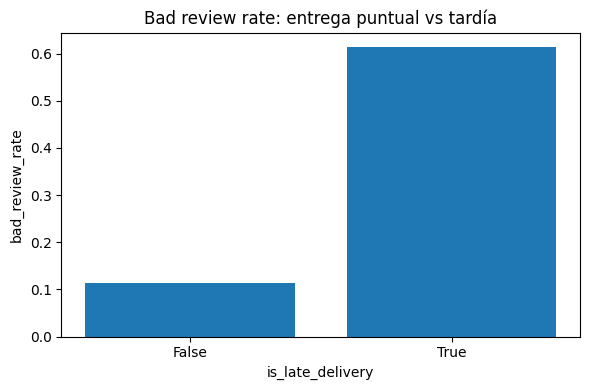

In [21]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(delay_review_summary["is_late_delivery"].astype(str), delay_review_summary["bad_review_rate"])
ax.set_title("Bad review rate: entrega puntual vs tardía")
ax.set_xlabel("is_late_delivery")
ax.set_ylabel("bad_review_rate")
plt.tight_layout()
plt.show()

## 2.1. Diagnóstico por categoría

Aquí se identifican:
- categorías con mayor escala,
- categorías con peor experiencia,
- categorías con fricción logística,
- y categorías con mala experiencia incluso sin retraso.

In [22]:
category_diagnostics = (
    item_base.groupby("product_category", as_index=False)
    .agg(
        n_items=("quantity", "sum"),
        n_orders=("order_id", "nunique"),
        n_products=("product_id", "nunique"),
        total_revenue=("item_revenue", "sum"),
        total_gross_revenue=("gross_revenue", "sum"),
        avg_review_score=("review_score", "mean"),
        bad_review_rate=("is_bad_review", "mean"),
        neutral_or_worse_rate=("is_neutral_or_worse_review", "mean"),
        late_delivery_rate=("is_late_delivery", "mean"),
        avg_delay_days=("delivery_delay_days", "mean"),
    )
)

#### Categorías con mayor volumen

In [23]:
top_volume_categories = (
    category_diagnostics
    .sort_values("n_items", ascending=False)
    .head(15)
    .reset_index(drop=True)
)

top_volume_categories

,product_category,n_items,n_orders,n_products,total_revenue,total_gross_revenue,avg_review_score,bad_review_rate,neutral_or_worse_rate,late_delivery_rate,avg_delay_days
0,bed_bath_table,10953,9272,2991,"1,023,434.76","1,225,209.26",3.92,0.18,0.28,0.07,-11.66
1,health_beauty,9465,8647,2397,"1,233,131.72","1,412,089.53",4.19,0.12,0.20,0.08,-11.97
2,sports_leisure,8431,7530,2822,"954,852.55","1,118,256.91",4.17,0.13,0.20,0.06,-12.01
3,furniture_decor,8160,6307,2593,"711,927.69","880,329.92",3.95,0.18,0.27,0.07,-12.40
4,computers_accessories,7644,6530,1600,"888,724.61","1,032,723.77",3.99,0.17,0.25,0.06,-12.42
5,housewares,6795,5743,2282,"615,628.69","758,392.25",4.11,0.14,0.23,0.05,-12.30
6,watches_gifts,5859,5495,1300,"1,166,176.98","1,264,333.12",4.07,0.15,0.24,0.07,-11.92
7,telephony,4430,4093,1112,"309,860.23","379,202.62",3.99,0.15,0.26,0.07,-11.38
8,garden_tools,4268,3448,725,"470,495.28","567,145.68",4.08,0.15,0.23,0.07,-11.98
9,auto,4140,3810,1853,"578,966.65","669,454.75",4.12,0.14,0.21,0.07,-11.44


#### Categorías con peor experiencia general
Se filtran categorías con suficiente volumen de órdenes para evitar ruido estadístico.

In [24]:
worst_categories_general = (
    category_diagnostics
    .query("n_orders >= 30")
    .sort_values(
        ["bad_review_rate", "late_delivery_rate", "avg_review_score"],
        ascending=[False, False, True]
    )
    .reset_index(drop=True)
)

worst_categories_general.head(15)

,product_category,n_items,n_orders,n_products,total_revenue,total_gross_revenue,avg_review_score,bad_review_rate,neutral_or_worse_rate,late_delivery_rate,avg_delay_days
0,office_furniture,1668,1254,302,"268,154.31","335,211.36",3.51,0.25,0.40,0.08,-11.85
1,fashion_male_clothing,125,106,89,"10,452.33","12,514.95",3.76,0.25,0.30,0.06,-12.71
2,fixed_telephony,255,212,113,"55,315.21","59,816.54",3.76,0.23,0.30,0.04,-14.72
3,party_supplies,42,38,25,"4,465.19","5,285.38",3.83,0.21,0.33,0.00,-15.12
4,audio,362,348,58,"50,570.60","56,255.32",3.84,0.21,0.31,0.12,-10.15
5,home_confort,429,392,111,"58,008.45","66,438.22",3.85,0.20,0.32,0.09,-9.81
6,unknown,1537,1392,584,"170,726.63","197,695.69",3.94,0.19,0.26,0.07,-11.41
7,furniture_mattress_and_upholstery,37,37,10,"4,323.38","5,904.75",3.89,0.19,0.27,0.14,-7.16
8,bed_bath_table,10953,9272,2991,"1,023,434.76","1,225,209.26",3.92,0.18,0.28,0.07,-11.66
9,furniture_decor,8160,6307,2593,"711,927.69","880,329.92",3.95,0.18,0.27,0.07,-12.40


#### Categorías con mayor fricción logística

In [25]:
late_category_diagnostics = (
    category_diagnostics
    .query("n_orders >= 30")
    .sort_values(["late_delivery_rate", "bad_review_rate"], ascending=[False, False])
    .reset_index(drop=True)
)

late_category_diagnostics.head(15)

,product_category,n_items,n_orders,n_products,total_revenue,total_gross_revenue,avg_review_score,bad_review_rate,neutral_or_worse_rate,late_delivery_rate,avg_delay_days
0,furniture_mattress_and_upholstery,37,37,10,"4,323.38","5,904.75",3.89,0.19,0.27,0.14,-7.16
1,audio,362,348,58,"50,570.60","56,255.32",3.84,0.21,0.31,0.12,-10.15
2,christmas_supplies,150,125,63,"8,737.84","11,928.75",4.07,0.13,0.20,0.10,-12.05
3,fashion_underwear_beach,127,117,52,"9,305.95","11,160.02",4.05,0.16,0.22,0.09,-10.93
4,home_confort,429,392,111,"58,008.45","66,438.22",3.85,0.20,0.32,0.09,-9.81
5,books_technical,263,256,122,"18,702.23","22,901.07",4.39,0.10,0.14,0.08,-11.31
6,office_furniture,1668,1254,302,"268,154.31","335,211.36",3.51,0.25,0.40,0.08,-11.85
7,baby,2982,2809,890,"400,421.84","466,727.65",4.08,0.15,0.23,0.08,-11.65
8,electronics,2729,2517,507,"155,043.93","200,723.09",4.07,0.15,0.23,0.08,-11.14
9,health_beauty,9465,8647,2397,"1,233,131.72","1,412,089.53",4.19,0.12,0.20,0.08,-11.97


#### Categorías con mala experiencia incluso sin retraso
Esto ayuda a identificar dolor secundario no logístico.

In [26]:
on_time_base = item_base.loc[~item_base["is_late_delivery"]].copy()

on_time_category_diagnostics = (
    on_time_base.groupby("product_category", as_index=False)
    .agg(
        n_orders=("order_id", "nunique"),
        n_items=("quantity", "sum"),
        total_revenue=("item_revenue", "sum"),
        avg_review_score=("review_score", "mean"),
        bad_review_rate=("is_bad_review", "mean"),
        neutral_or_worse_rate=("is_neutral_or_worse_review", "mean"),
    )
    .query("n_orders >= 30")
    .sort_values(["bad_review_rate", "avg_review_score"], ascending=[False, True])
    .reset_index(drop=True)
)

on_time_category_diagnostics.head(15)

,product_category,n_orders,n_items,total_revenue,avg_review_score,bad_review_rate,neutral_or_worse_rate
0,office_furniture,1153,1535,"246,403.14",3.62,0.22,0.37
1,fashion_male_clothing,101,118,"9,892.93",3.86,0.22,0.28
2,party_supplies,38,42,"4,465.19",3.83,0.21,0.33
3,fixed_telephony,202,245,"52,055.33",3.83,0.21,0.29
4,home_confort,355,389,"53,170.39",4.02,0.16,0.28
5,unknown,1291,1422,"156,594.71",4.09,0.15,0.21
6,construction_tools_safety,155,178,"38,443.47",4.05,0.15,0.22
7,furniture_decor,5858,7586,"653,411.75",4.07,0.15,0.24
8,home_construction,454,561,"75,604.74",4.06,0.15,0.23
9,bed_bath_table,8583,10183,"944,199.66",4.05,0.14,0.25


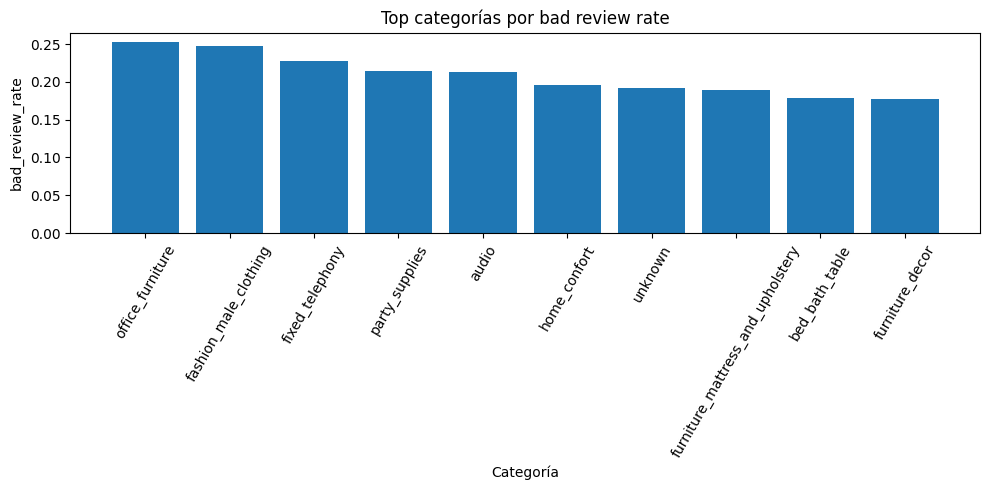

In [27]:
plot_df = worst_categories_general.head(10)

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(plot_df["product_category"], plot_df["bad_review_rate"])
ax.set_title("Top categorías por bad review rate")
ax.set_xlabel("Categoría")
ax.set_ylabel("bad_review_rate")
ax.tick_params(axis="x", rotation=60)
plt.tight_layout()
plt.show()

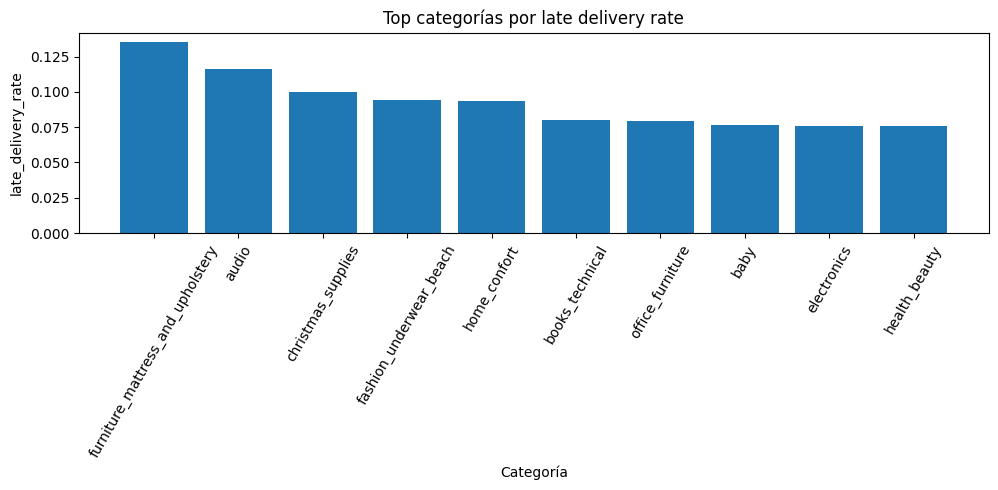

In [28]:
plot_df = late_category_diagnostics.head(10)

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(plot_df["product_category"], plot_df["late_delivery_rate"])
ax.set_title("Top categorías por late delivery rate")
ax.set_xlabel("Categoría")
ax.set_ylabel("late_delivery_rate")
ax.tick_params(axis="x", rotation=60)
plt.tight_layout()
plt.show()

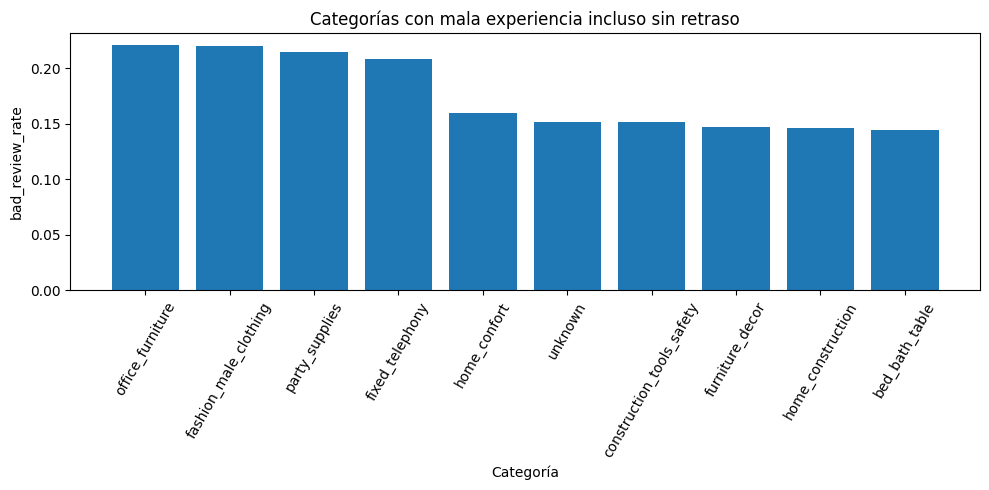

In [29]:
plot_df = on_time_category_diagnostics.head(10)

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(plot_df["product_category"], plot_df["bad_review_rate"])
ax.set_title("Categorías con mala experiencia incluso sin retraso")
ax.set_xlabel("Categoría")
ax.set_ylabel("bad_review_rate")
ax.tick_params(axis="x", rotation=60)
plt.tight_layout()
plt.show()

### 2.2. Matriz de dolor: escala vs mala experiencia

Esta vista es útil para priorización:
- eje X: volumen
- eje Y: bad_review_rate
- tamaño: ingresos

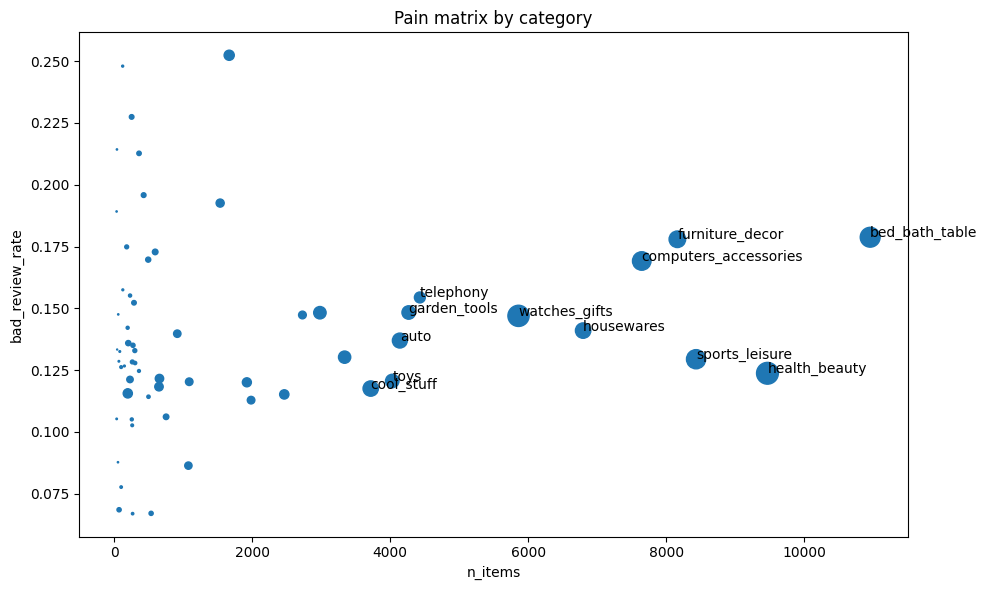

In [30]:
plot_df = category_diagnostics.query("n_orders >= 30").copy()

fig, ax = plt.subplots(figsize=(10, 6))
scatter = ax.scatter(
    plot_df["n_items"],
    plot_df["bad_review_rate"],
    s=plot_df["total_revenue"] / 5000,
)

for _, row in plot_df.sort_values("n_items", ascending=False).head(12).iterrows():
    ax.annotate(row["product_category"], (row["n_items"], row["bad_review_rate"]))

ax.set_title("Pain matrix by category")
ax.set_xlabel("n_items")
ax.set_ylabel("bad_review_rate")
plt.tight_layout()
plt.show()

## 2.3. Productos asociados a mala experiencia

Se separan dos vistas:
- productos extremos por mala experiencia,
- productos de alto impacto con mala experiencia.

In [31]:
product_diagnostics = (
    item_base.groupby("product_id", as_index=False)
    .agg(
        product_category=("product_category", lambda s: s.mode().iloc[0] if not s.mode().empty else "unknown"),
        n_items=("quantity", "sum"),
        n_orders=("order_id", "nunique"),
        total_revenue=("item_revenue", "sum"),
        avg_review_score=("review_score", "mean"),
        bad_review_rate=("is_bad_review", "mean"),
        neutral_or_worse_rate=("is_neutral_or_worse_review", "mean"),
        late_delivery_rate=("is_late_delivery", "mean"),
        avg_delay_days=("delivery_delay_days", "mean"),
    )
)


In [32]:
### Productos extremos por mala experiencia
worst_products = (
    product_diagnostics
    .query("n_orders >= 10")
    .sort_values(
        ["bad_review_rate", "late_delivery_rate", "avg_review_score"],
        ascending=[False, False, True]
    )
    .reset_index(drop=True)
)

worst_products.head(30)

,product_id,product_category,n_items,n_orders,total_revenue,avg_review_score,bad_review_rate,neutral_or_worse_rate,late_delivery_rate,avg_delay_days
0,fd0065af7f09af4b82a0ca8f3eed1852,auto,10,10,"19,999.90",1.20,0.90,1.00,0.90,8.70
1,cd46a885543f0e169a49f1eb25c04e43,computers_accessories,30,28,"2,999.70",1.83,0.77,0.80,0.00,-24.60
2,b1d207586fca400a2370d50a9ba1da98,unknown,47,42,"7,003.00",1.91,0.74,0.81,0.11,-7.83
3,6d2fde7d12bb6ff367dbda120ba8828e,computers_accessories,18,12,395.50,2.06,0.72,0.78,0.00,-9.56
4,16bf176650a888512655cc94f61860e3,watches_gifts,13,11,507.00,2.23,0.69,0.69,0.23,-6.92
5,b36f3c918c91478c4559160022d3f14e,unknown,15,15,"2,250.00",1.79,0.67,0.87,0.53,0.47
6,145028037adecb27b1a58cf9597676cc,office_furniture,14,10,"5,586.00",2.43,0.64,0.64,0.00,-12.29
7,0a9bdadab17a9b0f258f64d11a0adf7b,furniture_decor,22,10,"1,829.56",2.36,0.64,0.68,0.00,-17.09
8,43ee88561093499d9e571d4db5f20b79,furniture_decor,20,13,218.00,2.55,0.60,0.70,0.15,-9.50
9,86ecc269de40ba13205e7beeee12f26f,telephony,12,12,355.88,2.67,0.58,0.58,0.25,-2.58


In [33]:
### Productos de alto impacto con mala experiencia
#Filtramos productos con algo más de escala para evitar concentrarnos solo en casos pequeños.

high_impact_bad_products = (
    product_diagnostics
    .query("n_orders >= 20")
    .sort_values(
        ["bad_review_rate", "total_revenue", "n_items"],
        ascending=[False, False, False]
    )
    .reset_index(drop=True)
)

high_impact_bad_products.head(20)


,product_id,product_category,n_items,n_orders,total_revenue,avg_review_score,bad_review_rate,neutral_or_worse_rate,late_delivery_rate,avg_delay_days
0,cd46a885543f0e169a49f1eb25c04e43,computers_accessories,30,28,"2,999.70",1.83,0.77,0.80,0.00,-24.60
1,b1d207586fca400a2370d50a9ba1da98,unknown,47,42,"7,003.00",1.91,0.74,0.81,0.11,-7.83
2,89b121bee266dcd25688a1ba72eefb61,computers_accessories,63,57,"5,033.70",2.49,0.57,0.67,0.10,-10.76
3,25c38557cf793876c5abdd5931f922db,baby,38,38,"38,907.32",2.68,0.53,0.61,0.21,-6.45
4,7b35ccd93a2184646c03b70326626923,sports_leisure,23,20,"3,599.30",2.68,0.52,0.61,0.09,-14.22
5,0cf41187284d7f099adc8415a743ebbd,baby,34,32,"1,220.60",2.91,0.50,0.53,0.18,-10.00
6,51f876eb62be778c757503cf7f8a3b74,health_beauty,32,22,324.60,2.94,0.50,0.53,0.12,-11.41
7,1dec4c88c685d5a07bf01dcb0f8bf9f8,auto,35,35,"19,965.00",2.74,0.49,0.63,0.37,-1.86
8,362b773250263786dd58670d2df42c3b,sports_leisure,73,49,"3,782.70",2.92,0.47,0.51,0.05,-8.66
9,fb01a5fc09b9b9563c2ee41a22f07d54,consoles_games,24,24,"16,731.79",2.87,0.46,0.54,0.25,-8.12


## 2.4. Respuesta ejecutiva Q2

In [34]:
summary_q2 = {
    "overall_pain_metrics": overall_pain.to_dict(orient="records"),
    "delay_vs_review": delay_review_summary.to_dict(orient="records"),
    "worst_categories_general": worst_categories_general.head(10).to_dict(orient="records"),
    "worst_categories_logistics": late_category_diagnostics.head(10).to_dict(orient="records"),
    "worst_categories_without_delay": on_time_category_diagnostics.head(10).to_dict(orient="records"),
    "worst_products": worst_products.head(10).to_dict(orient="records"),
    "high_impact_bad_products": high_impact_bad_products.head(10).to_dict(orient="records"),
}

summary_q2

{'overall_pain_metrics': [{'metric': 'avg_review_score',
   'value': 4.0820441315412515},
  {'metric': 'bad_review_rate', 'value': 0.1462018022269209},
  {'metric': 'neutral_or_worse_review_rate', 'value': 0.23006070945670026},
  {'metric': 'late_delivery_rate', 'value': 0.06591830993584218},
  {'metric': 'avg_delivery_delay_days', 'value': -12.02904101135322},
  {'metric': 'median_delivery_delay_days', 'value': -13.0}],
 'delay_vs_review': [{'is_late_delivery': False,
   'n_items': 102933,
   'avg_review_score': 4.20840054617563,
   'bad_review_rate': 0.11324842373194213,
   'neutral_or_worse_rate': 0.19572926078128491},
  {'is_late_delivery': True,
   'n_items': 7264,
   'avg_review_score': 2.2573062261753494,
   'bad_review_rate': 0.6131607929515418,
   'neutral_or_worse_rate': 0.7165473568281938}],
 'worst_categories_general': [{'product_category': 'office_furniture',
   'n_items': 1668,
   'n_orders': 1254,
   'n_products': 302,
   'total_revenue': 268154.31,
   'total_gross_reven